# Detect and Remove the Outliers using Python

#### 1. Visualizing and Removing Outliers Using Box Plots

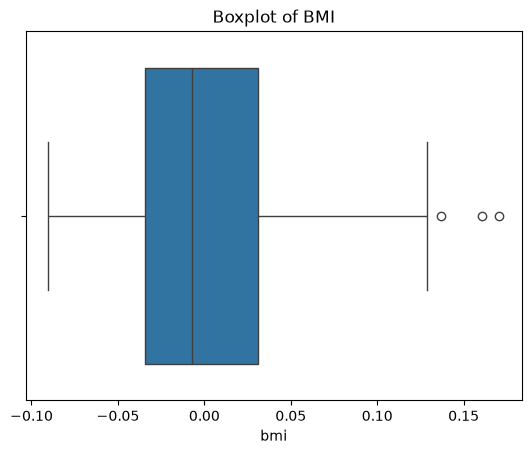

In [1]:
import sklearn
from sklearn.datasets import load_diabetes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

diabetes = load_diabetes()

column_name = diabetes.feature_names
df_diabetics = pd.DataFrame(diabetes.data, columns=column_name)

sns.boxplot(x=df_diabetics['bmi'])
plt.title('Boxplot of BMI')
plt.show()

Removing Outliers

To remove outliers, we can define a threshold value and filter the data.

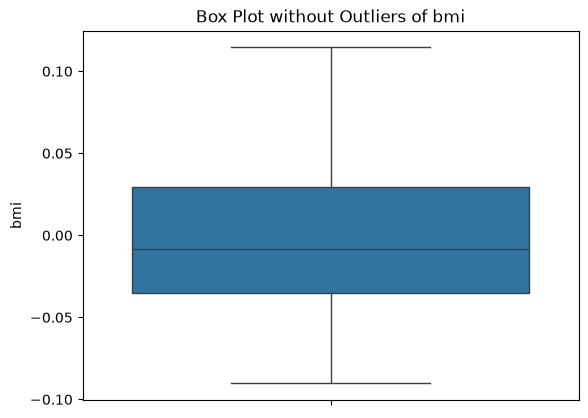

In [2]:
def removal_box_plot(df, column, threshold):
    removed_outliers = df[df[column] <= threshold]

    sns.boxplot(removed_outliers[column])
    plt.title(f'Box Plot without Outliers of {column}')
    plt.show()
    return removed_outliers

threshold_value = 0.12

no_outliers = removal_box_plot(df_diabetics, 'bmi', threshold_value)

2. Visualizing and Removing Outliers Using Scatter Plots

Scatter plots help show the relationship between two variables. They are useful when working with paired numerical data. In a scatter plot, outliers appear as points that are far away from the main group of data points.

<Axes: xlabel='bmi', ylabel='bp'>

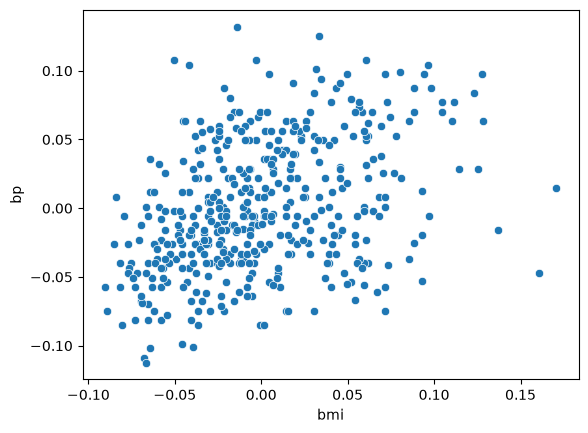

In [5]:
sns.scatterplot(data = df_diabetics,x='bmi',y='bp')

Removing Outliers

np.where(): Used to find the positions (indices) in the DataFrame where a condition is true.
(df_diabetics['bmi'] > 0.12) and (df_diabetics['bp'] < 0.8): This condition identifies outliers where bmi is greater than 0.12 and bp is less than 0.8.

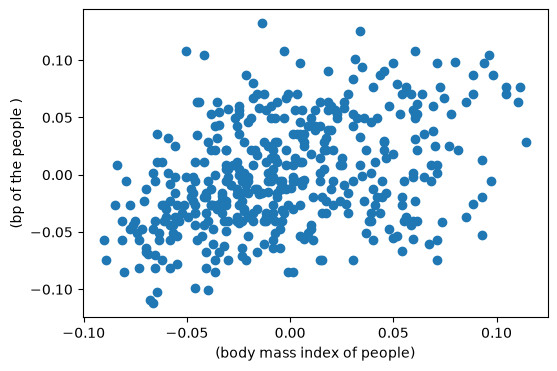

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

outlier_indices = np.where((df_diabetics['bmi'] > 0.12) & (df_diabetics['bp'] < 0.8))

no_outliers = df_diabetics.drop(outlier_indices[0])

fig, ax_no_outliers = plt.subplots(figsize=(6, 4))
ax_no_outliers.scatter(no_outliers['bmi'], no_outliers['bp'])
ax_no_outliers.set_xlabel('(body mass index of people)')
ax_no_outliers.set_ylabel('(bp of the people )')
plt.show()

#### 3. Z-Score Method for Outlier Detection

The Z-score, also called the standard score, shows how far a data point is from the mean in terms of standard deviations. If the Z-score is greater than a chosen threshold , the value is considered an outlier.

Z-scores are calculated for the 'age' column in df_diabetics.

The zscore() function from SciPy stats is used.

The result z shows how far each value is from the mean in standard deviations.

In [7]:
from scipy import stats
import numpy as np
z = np.abs(stats.zscore(df_diabetics['age']))
print(z)

[0.80050009 0.03956713 1.79330681 1.87244107 0.11317236 1.94881082
 0.9560041  1.33508832 0.87686984 1.49059233 2.02518057 0.57139085
 0.34228161 0.11317236 0.95323959 1.1087436  0.11593688 1.48782782
 0.80326461 0.57415536 1.03237385 1.79607132 1.79607132 0.95323959
 1.33785284 1.41422259 2.25428981 0.49778562 1.10597908 1.41145807
 1.26148309 0.49778562 0.72413034 0.6477606  0.34228161 1.02960933
 0.26591186 0.19230663 0.03956713 0.03956713 0.11317236 2.10155031
 1.26148309 0.41865135 0.95323959 0.57139085 1.18511334 1.64333183
 1.41145807 0.87963435 0.72413034 1.25871858 1.1087436  0.19230663
 1.03237385 0.87963435 0.87963435 0.57415536 0.87686984 1.33508832
 1.49059233 0.87963435 0.57415536 0.72689486 1.41145807 0.9560041
 0.19230663 0.87686984 0.80050009 0.34228161 0.03956713 0.03956713
 1.33508832 0.26591186 0.26591186 0.19230663 0.65052511 2.02518057
 0.11317236 2.17792006 1.48782782 0.26591186 0.34504612 0.80326461
 0.03680262 0.95323959 1.49059233 0.95323959 1.1087436  0.95600

Output:

An outlier threshold is usually set to 3.0. This is because about 99.7% of data points in a normal (Gaussian) distribution lie within 
±
3
±3 standard deviations from the mean.

Z scores
Removing Outliers: Trimming and Capping

After identifying outliers using the Z-score method, we can handle them in two common ways: trimming or capping.

Trimming removes the rows that contain outliers from the dataset.
Capping keeps the rows but replaces extreme values with a predefined limit.

In [8]:
import numpy as np

threshold_z = 2

outlier_indices = np.where(z > threshold_z)[0]
no_outliers = df_diabetics.drop(outlier_indices)

print("Original DataFrame Shape:", df_diabetics.shape)
print("DataFrame Shape after Removing Outliers:", no_outliers.shape)

Original DataFrame Shape: (442, 10)
DataFrame Shape after Removing Outliers: (426, 10)


In [9]:
# Capping Outliers


threshold_z = 2

df_capped = df_diabetics.copy()

df_capped['age'] = np.where(z > threshold_z,
                            df_diabetics['age'].mean() + threshold_z * df_diabetics['age'].std(),
                            df_diabetics['age'])

print("Original DataFrame Shape:", df_diabetics.shape)
print("DataFrame Shape after Capping Outliers:", df_capped.shape)

Original DataFrame Shape: (442, 10)
DataFrame Shape after Capping Outliers: (442, 10)


### 4. Interquartile Range (IQR) Method
The IQR (Interquartile Range) method is a common and reliable technique for detecting outliers. It works well even when the data is skewed and identifies extreme values using quartiles. The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1):


IQR=Q3−Q1

Here, we calculate the IQR for the 'bmi' column in df_diabetics. First Q1 and Q3 are found, then IQR = Q3 − Q1, which shows the spread of the middle 50% of the data.

In [13]:
Q1 = np.percentile(df_diabetics['bmi'], 25, method='midpoint')
Q3 = np.percentile(df_diabetics['bmi'], 75, method='midpoint')
IQR = Q3 - Q1
print(IQR)

q1,q3 = df_diabetics['bmi'].quantile([0.25,0.75])
print(q3-q1)

0.06520763046978838
0.06547708348825859


To identify outliers, we define upper and lower limits using the IQR value. Any value outside this range is treated as an outlier.


upper=Q3+1.5∗IQR

lower=Q1−1.5∗IQR

In [14]:
upper = Q3+1.5*IQR
upper_array = np.array(df_diabetics['bmi'] >= upper)
print("Upper Bound:", upper)
print(upper_array.sum())

lower = Q1-1.5*IQR
lower_array = np.array(df_diabetics['bmi'] <= lower)
print("Lower Bound:", lower)
print(lower_array.sum())

Upper Bound: 0.12879000811776306
3
Lower Bound: -0.13204051376139045
0


Removing Outliers: Trimming and Capping

Trimming Outliers

In [15]:
import numpy as np
import sklearn
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes()

column_name = diabetes.feature_names
df_diabetes = pd.DataFrame(diabetes.data)
df_diabetes.columns = column_name

print("Old Shape:", df_diabetes.shape)

Q1 = df_diabetes['bmi'].quantile(0.25)
Q3 = df_diabetes['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

upper_array = np.where(df_diabetes['bmi'] >= upper)[0]
lower_array = np.where(df_diabetes['bmi'] <= lower)[0]

df_diabetes.drop(index=upper_array, inplace=True)
df_diabetes.drop(index=lower_array, inplace=True)

print("New Shape:", df_diabetes.shape)

Old Shape: (442, 10)
New Shape: (439, 10)


Capping Outliers

In [16]:
df_capped = df_diabetes.copy()

df_capped['bmi'] = np.where(df_capped['bmi'] > upper, upper, df_capped['bmi'])
df_capped['bmi'] = np.where(df_capped['bmi'] < lower, lower, df_capped['bmi'])

print("Shape after Capping:", df_capped.shape)

Shape after Capping: (439, 10)
